<a href="https://colab.research.google.com/github/Sanjaiguru06/ML-Practice-Experiments/blob/main/Experiment5_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

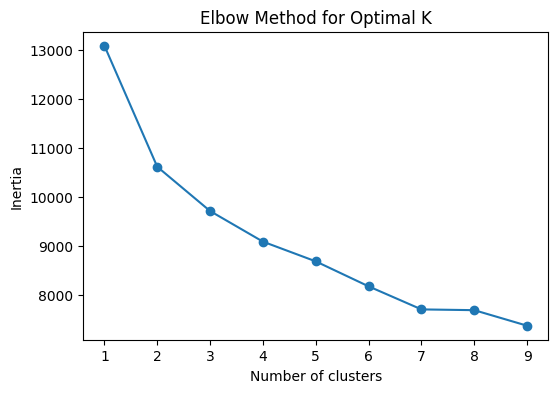

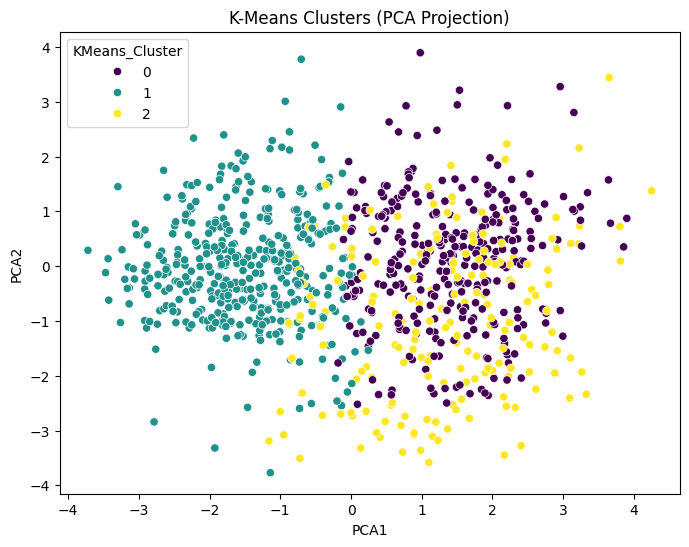

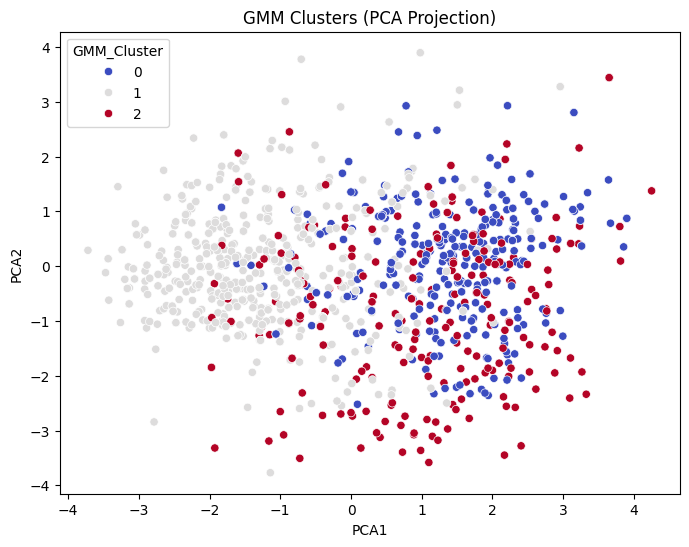

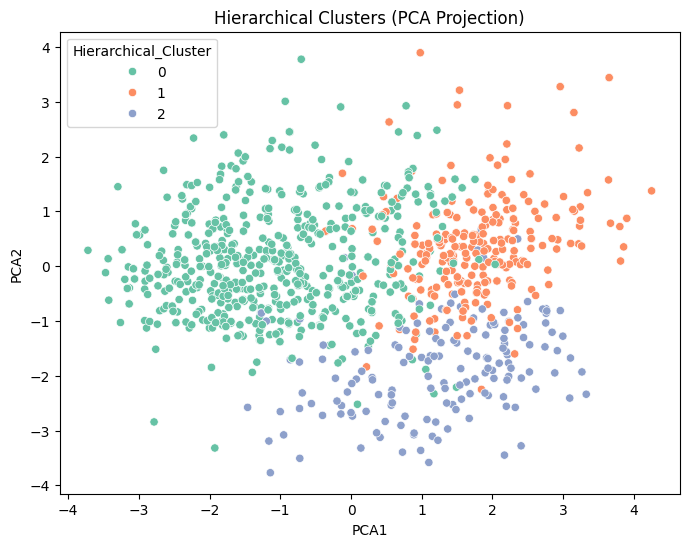

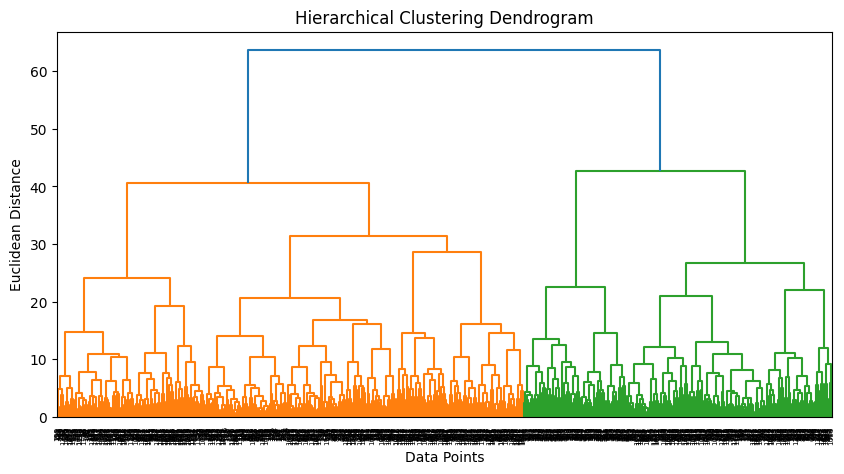


Cluster Distribution (K-Means):
KMeans_Cluster
1    550
0    416
2    224
Name: count, dtype: int64

Cluster Distribution (GMM):
GMM_Cluster
1    586
0    350
2    254
Name: count, dtype: int64

Cluster Distribution (Hierarchical):
Hierarchical_Cluster
0    717
1    315
2    158
Name: count, dtype: int64

✅ Clustering completed! Output saved as 'clustered_output.csv'


In [2]:
# Experiment 5: Clustering Techniques
# K-Means, Gaussian Mixture Model (GMM), and Hierarchical Clustering

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv("/content/sample_data/dataset.csv")
X = df.drop(columns=['target'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

inertia = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

gmm = GaussianMixture(n_components=3, random_state=42)
df['GMM_Cluster'] = gmm.fit_predict(X_scaled)
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='viridis')
plt.title("K-Means Clusters (PCA Projection)")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='GMM_Cluster', palette='coolwarm')
plt.title("GMM Clusters (PCA Projection)")
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Hierarchical_Cluster', palette='Set2')
plt.title("Hierarchical Clusters (PCA Projection)")
plt.show()

plt.figure(figsize=(10,5))
dendrogram(linkage(X_scaled, method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()


print("\nCluster Distribution (K-Means):")
print(df['KMeans_Cluster'].value_counts())
print("\nCluster Distribution (GMM):")
print(df['GMM_Cluster'].value_counts())
print("\nCluster Distribution (Hierarchical):")
print(df['Hierarchical_Cluster'].value_counts())

df.to_csv("clustered_output.csv", index=False)
print("\n✅ Clustering completed! Output saved as 'clustered_output.csv'")
